# Track B: Transformer Window Embeddings for Regime Discovery

这个 notebook 现在是展开版：Transformer 结构、训练循环、embedding 提取、聚类和 HMM 对比都直接写在 notebook 里。  
This notebook is now the expanded version: the Transformer architecture, training loop, embedding extraction, clustering, and HMM comparison are all written directly inside the notebook.

我也把默认训练配置换成了更偏防过拟合的一版。  
I also switched the default training configuration to a more overfitting-resistant setup.


In [1]:
import importlib.util

# 只检查依赖，不在 notebook 内自动安装，避免 Windows/Jupyter 子进程编码问题。
# Check dependencies without installing inside the notebook to avoid Windows/Jupyter subprocess encoding issues.
REQUIRED_PACKAGES = ["torch", "yfinance", "hmmlearn", "sklearn"]
missing_packages = [pkg for pkg in REQUIRED_PACKAGES if importlib.util.find_spec(pkg) is None]

if missing_packages:
    missing_text = ", ".join(missing_packages)
    raise ImportError(
        f"Missing packages: {missing_text}. 请先在当前环境里安装，例如: pip install torch yfinance hmmlearn scikit-learn"
    )

print("Dependency check passed / 依赖检查通过: torch, yfinance, hmmlearn, sklearn")


Dependency check passed / 依赖检查通过: torch, yfinance, hmmlearn, sklearn


In [2]:
import math
import os
import random
import warnings
from dataclasses import dataclass

# Windows + MKL 下聚类与线代库容易反复给出线程警告，这里先把线程数限制在 1。
# On Windows + MKL, clustering and linear algebra libraries can emit repeated thread warnings, so we cap threads at 1.
os.environ.setdefault("OMP_NUM_THREADS", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL.*",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message="MiniBatchKMeans is known to have a memory leak on Windows with MKL.*",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message="enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True",
    category=UserWarning,
)
torch.set_num_threads(1)


@dataclass
class TrackBConfig:
    start_date: str = "2015-01-01"
    window_size: int = 60
    mask_ratio: float = 0.20
    batch_size: int = 64
    num_epochs: int = 100
    learning_rate: float = 1e-4
    train_ratio: float = 0.8
    d_model: int = 128
    embedding_dim: int = 64
    n_heads: int = 4
    num_layers: int = 2
    dropout: float = 0.10
    state_candidates: tuple = (2, 3, 4)
    n_restarts: int = 8
    random_state: int = 42
    log_every: int = 1
    early_stopping_patience: int = 20
    min_epochs: int = 5


MARKET_TICKERS = {
    "SPY": "US equities / 美国股票",
    "TLT": "Long Treasuries / 长久期美债",
    "GLD": "Gold / 黄金",
    "UUP": "US dollar ETF proxy / 美元 ETF 代理",
    "HYG": "High yield credit / 高收益信用",
    "LQD": "Investment-grade credit / 投资级信用",
    "^VIX": "Volatility index / 波动率指数",
}

FRED_SERIES = {
    "DGS10": "10-Year Treasury yield / 10 年期美债收益率",
    "DGS2": "2-Year Treasury yield / 2 年期美债收益率",
}

REGIME_NAME_CN = {
    "stress": "压力",
    "transition": "过渡",
    "recovery": "修复",
    "risk-on": "风险偏好",
    "risk-off": "风险规避",
}


def set_seed(seed: int) -> None:
    # 固定随机种子，让 HMM、Transformer 和聚类结果更可复现。
    # Fix all random seeds so the HMM, Transformer, and clustering results are more reproducible.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


In [3]:
def load_fred_series(series_id: str) -> pd.DataFrame:
    # FRED 可以直接通过 CSV 拉取，这样脚本不需要额外依赖。
    # FRED can be pulled as a simple CSV, which keeps the script dependency-light.
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    frame = pd.read_csv(url)

    date_col = next((col for col in ["DATE", "date", "observation_date"] if col in frame.columns), None)
    if date_col is None:
        raise ValueError(f"Could not find a date column in FRED response for {series_id}. Columns: {list(frame.columns)}")

    value_cols = [col for col in frame.columns if col != date_col]
    if not value_cols:
        raise ValueError(f"Could not find a value column in FRED response for {series_id}. Columns: {list(frame.columns)}")

    value_col = value_cols[0]
    frame[date_col] = pd.to_datetime(frame[date_col])
    frame[value_col] = pd.to_numeric(frame[value_col], errors="coerce")
    return frame[[date_col, value_col]].rename(columns={date_col: "date", value_col: series_id}).set_index("date")


def download_market_and_macro(start_date: str):
    # 先下载一份完整的市场价格面板，再把 FRED 的曲线数据对齐到市场交易日。
    # Download a full market price panel first, then align the FRED curve data to market trading days.
    raw = yf.download(
        tickers=list(MARKET_TICKERS),
        start=start_date,
        auto_adjust=True,
        progress=False,
    )

    close = raw["Close"].copy()
    fred_df = pd.concat([load_fred_series(series_id) for series_id in FRED_SERIES], axis=1).sort_index()
    fred_df = fred_df.reindex(close.index).ffill()
    fred_df["curve_slope_10y2y"] = fred_df["DGS10"] - fred_df["DGS2"]
    fred_df["curve_slope_change"] = fred_df["curve_slope_10y2y"].diff()
    return close, fred_df


def build_hmm_features(close: pd.DataFrame, macro: pd.DataFrame) -> pd.DataFrame:
    # 这里重建 Track A 风格的特征，用来生成参考 HMM 标签。
    # Rebuild the Track A-style feature set here so we can generate the reference HMM labels.
    close = close.rename(columns={"^VIX": "VIX"}).dropna(how="all")
    returns = close.pct_change()
    credit_spread_proxy = np.log(close["HYG"] / close["LQD"])

    hmm_features = pd.DataFrame(
        {
            "SPY_ret": returns["SPY"],
            "SPY_vol_21d": returns["SPY"].rolling(21).std() * np.sqrt(252),
            "VIX_level": close["VIX"],
            "TLT_ret": returns["TLT"],
            "GLD_ret": returns["GLD"],
            "UUP_ret": returns["UUP"],
            "credit_spread_proxy": credit_spread_proxy,
            "curve_slope_10y2y": macro["curve_slope_10y2y"],
            "corr_60d_SPY_TLT": returns["SPY"].rolling(60).corr(returns["TLT"]),
        }
    )

    return hmm_features.dropna()


def build_sequence_panel(close: pd.DataFrame, macro: pd.DataFrame) -> pd.DataFrame:
    # Track B 的输入是日频序列面板，更接近“多资产收益率 + 利率变化”的序列学习问题。
    # Track B uses a daily sequence panel, which is closer to a sequence-learning problem over multi-asset returns plus rate changes.
    close = close.rename(columns={"^VIX": "VIX"}).dropna(how="all")
    returns = close.pct_change()

    sequence_df = pd.DataFrame(
        {
            "SPY_ret": returns["SPY"],
            "TLT_ret": returns["TLT"],
            "GLD_ret": returns["GLD"],
            "UUP_ret": returns["UUP"],
            "HYG_ret": returns["HYG"],
            "LQD_ret": returns["LQD"],
            "VIX_ret": np.log(close["VIX"]).diff(),
            "curve_slope_change": macro["curve_slope_change"],
        }
    )

    return sequence_df.dropna()


def hmm_parameter_count(n_states: int, n_features: int, covariance_type: str = "diag") -> int:
    startprob = n_states - 1
    transmat = n_states * (n_states - 1)
    means = n_states * n_features

    if covariance_type == "diag":
        covars = n_states * n_features
    elif covariance_type == "full":
        covars = n_states * n_features * (n_features + 1) // 2
    else:
        raise ValueError(f"Unsupported covariance_type: {covariance_type}")

    return startprob + transmat + means + covars


def fit_best_hmm(
    X: np.ndarray,
    n_states: int,
    covariance_type: str = "diag",
    n_restarts: int = 8,
    n_iter: int = 500,
    random_state: int = 42,
):
    # 多次随机重启，减少 HMM 落在差局部最优的概率。
    # Use multiple random restarts to reduce the chance that the HMM lands in a poor local optimum.
    best_model = None
    best_score = -np.inf

    for seed in range(random_state, random_state + n_restarts):
        model = GaussianHMM(
            n_components=n_states,
            covariance_type=covariance_type,
            n_iter=n_iter,
            random_state=seed,
        )
        model.fit(X)
        score = model.score(X)
        if score > best_score:
            best_score = score
            best_model = model

    return best_model, best_score


def select_hmm_by_bic(
    X: np.ndarray,
    state_candidates,
    covariance_type: str = "diag",
    n_restarts: int = 8,
    random_state: int = 42,
):
    rows = []
    models = {}
    n_features = X.shape[1]
    n_obs = X.shape[0]

    for n_states in state_candidates:
        model, loglik = fit_best_hmm(
            X=X,
            n_states=n_states,
            covariance_type=covariance_type,
            n_restarts=n_restarts,
            random_state=random_state,
        )
        n_params = hmm_parameter_count(n_states, n_features, covariance_type=covariance_type)
        bic = -2 * loglik + n_params * np.log(n_obs)
        rows.append({"n_states": n_states, "loglik": loglik, "n_params": n_params, "bic": bic})
        models[n_states] = model

    summary = pd.DataFrame(rows).sort_values("n_states").reset_index(drop=True)
    best_n_states = int(summary.sort_values("bic").iloc[0]["n_states"])
    return summary, models, best_n_states


def label_hmm_states(feature_frame: pd.DataFrame, state_col: str = "hmm_state"):
    # 用启发式风险分数给 HMM 状态起名字，便于后面对比 Transformer clusters。
    # Use a heuristic risk score to name HMM states so that later comparison with Transformer clusters is easier.
    metric_cols = [
        "SPY_ret",
        "SPY_vol_21d",
        "VIX_level",
        "credit_spread_proxy",
        "curve_slope_10y2y",
        "corr_60d_SPY_TLT",
    ]
    state_means = feature_frame.groupby(state_col)[metric_cols].mean()
    state_stds = state_means.std(ddof=0).replace(0, 1)
    z = (state_means - state_means.mean()) / state_stds

    risk_score = (
        z["SPY_ret"].fillna(0)
        - z["SPY_vol_21d"].fillna(0)
        - z["VIX_level"].fillna(0)
        + z["credit_spread_proxy"].fillna(0)
        + 0.75 * z["curve_slope_10y2y"].fillna(0)
        - 0.5 * z["corr_60d_SPY_TLT"].fillna(0)
    )

    ordered_states = risk_score.sort_values().index.tolist()
    n_states = len(ordered_states)

    if n_states == 2:
        names_en = ["risk-off", "risk-on"]
    elif n_states == 3:
        names_en = ["stress", "transition", "risk-on"]
    elif n_states == 4:
        names_en = ["stress", "transition", "recovery", "risk-on"]
    else:
        names_en = [f"state_{i}" for i in range(n_states)]

    label_map_en = {state: names_en[i] for i, state in enumerate(ordered_states)}
    label_map_cn = {state: REGIME_NAME_CN.get(label_map_en[state], label_map_en[state]) for state in ordered_states}
    return label_map_en, label_map_cn, ordered_states, risk_score.sort_values()


def make_windows(frame: pd.DataFrame, window_size: int):
    # 把日频序列切成固定长度窗口，每个窗口对应一个结束日期。
    # Slice the daily sequence into fixed-length windows, each associated with an end date.
    values = frame.values.astype(np.float32)
    windows = []
    end_dates = []

    for end in range(window_size, len(frame) + 1):
        start = end - window_size
        windows.append(values[start:end])
        end_dates.append(frame.index[end - 1])

    return np.stack(windows), pd.Index(end_dates, name="date")


def shade_segments(ax, index, labels, colors, alpha: float = 0.16):
    start = 0
    index = pd.Index(index)
    labels = pd.Series(labels).reset_index(drop=True)

    while start < len(labels):
        current = labels.iloc[start]
        end = start
        while end + 1 < len(labels) and labels.iloc[end + 1] == current:
            end += 1
        ax.axvspan(index[start], index[end], color=colors[current], alpha=alpha, lw=0)
        start = end + 1


In [4]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, : x.size(1)]


class MaskedReturnTransformer(nn.Module):
    def __init__(
        self,
        input_dim: int,
        d_model: int,
        embedding_dim: int,
        n_heads: int,
        num_layers: int,
        dropout: float,
        max_len: int,
    ):
        super().__init__()
        # 先对原始特征做归一化，再把“哪些位置被遮罩”显式编码进输入表示。
        # Normalize the raw features first, then explicitly encode which positions were masked.
        self.input_norm = nn.LayerNorm(input_dim)
        self.input_proj = nn.Linear(input_dim, d_model)
        self.mask_proj = nn.Linear(input_dim, d_model, bias=False)
        self.pos_encoder = SinusoidalPositionalEncoding(d_model=d_model, max_len=max_len)
        self.pos_dropout = nn.Dropout(dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model),
        )
        self.reconstruct_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, input_dim),
        )
        self.pool_score = nn.Linear(d_model, 1)
        self.embedding_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, embedding_dim),
        )

    def forward(self, x: torch.Tensor, mask: torch.Tensor | None = None):
        normalized_x = self.input_norm(x)
        hidden = self.input_proj(normalized_x)
        if mask is not None:
            hidden = hidden + self.mask_proj(mask.float())
        hidden = self.pos_dropout(self.pos_encoder(hidden))
        hidden = self.encoder(hidden)
        reconstruction = self.reconstruct_head(hidden)
        pool_weights = torch.softmax(self.pool_score(hidden), dim=1)
        pooled = (hidden * pool_weights).sum(dim=1)
        embedding = self.embedding_head(pooled)
        return reconstruction, embedding


def sample_mask(x: torch.Tensor, mask_ratio: float) -> torch.Tensor:
    # 在每个 batch 内随机遮掉一部分位置，让模型去重建被遮掉的值。
    # Randomly mask part of each batch so the model must reconstruct the hidden values.
    mask = torch.rand_like(x) < mask_ratio
    flat = mask.reshape(mask.size(0), -1)
    empty_rows = flat.sum(dim=1) == 0
    if empty_rows.any():
        random_pos = torch.randint(0, flat.size(1), (int(empty_rows.sum().item()),), device=x.device)
        flat[empty_rows, random_pos] = True
    return flat.reshape_as(mask)


def masked_reconstruction_loss(
    model: nn.Module,
    batch: torch.Tensor,
    mask_ratio: float,
    mask: torch.Tensor | None = None,
):
    # 训练阶段继续随机采样 mask；验证阶段可以传入固定 mask，让曲线更可比。
    # Keep sampling random masks during training; allow a fixed mask during validation for a cleaner curve.
    if mask is None:
        mask = sample_mask(batch, mask_ratio)
    masked_batch = batch.clone()
    masked_batch[mask] = 0.0
    reconstruction, embeddings = model(masked_batch, mask=mask)
    loss = ((reconstruction - batch) ** 2)[mask].mean()
    return loss, reconstruction, embeddings


def train_transformer(windows: np.ndarray, cfg: TrackBConfig):
    # 把标准化后的窗口数据喂给 Transformer，做 masked reconstruction 训练。
    # Feed the standardized window data into the Transformer and train it with masked reconstruction.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    split_idx = max(1, int(len(windows) * cfg.train_ratio))
    train_windows = torch.tensor(windows[:split_idx], dtype=torch.float32)
    val_windows = torch.tensor(windows[split_idx:], dtype=torch.float32)
    all_windows = torch.tensor(windows, dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(train_windows), batch_size=cfg.batch_size, shuffle=True)
    if len(val_windows) > 0:
        # 固定验证集的 mask，避免每个 epoch 因为采样不同而让 val loss 抖得太厉害。
        # Freeze the validation masks so epoch-to-epoch val loss is comparable.
        val_masks = sample_mask(val_windows, cfg.mask_ratio)
        val_loader = DataLoader(TensorDataset(val_windows, val_masks), batch_size=cfg.batch_size, shuffle=False)
    else:
        val_loader = None

    model = MaskedReturnTransformer(
        input_dim=windows.shape[2],
        d_model=cfg.d_model,
        embedding_dim=cfg.embedding_dim,
        n_heads=cfg.n_heads,
        num_layers=cfg.num_layers,
        dropout=cfg.dropout,
        max_len=cfg.window_size,
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate)

    history = []
    best_state_dict = None
    best_val_loss = float("inf")
    no_improve_epochs = 0

    print(
        f"Training Transformer / 开始训练 Transformer | device={device} | windows={len(windows)} | "
        f"epochs={cfg.num_epochs} | batch_size={cfg.batch_size}",
        flush=True,
    )

    for epoch in range(1, cfg.num_epochs + 1):
        model.train()
        train_losses = []
        for (batch,) in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            loss, _, _ = masked_reconstruction_loss(model, batch, cfg.mask_ratio)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(float(loss.item()))

        train_loss = float(np.mean(train_losses))

        if val_loader is not None:
            model.eval()
            val_losses = []
            with torch.no_grad():
                for batch, val_mask in val_loader:
                    batch = batch.to(device)
                    val_mask = val_mask.to(device)
                    val_loss, _, _ = masked_reconstruction_loss(model, batch, cfg.mask_ratio, mask=val_mask)
                    val_losses.append(float(val_loss.item()))
            val_loss_value = float(np.mean(val_losses))
        else:
            val_loss_value = train_loss

        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss_value})

        if cfg.log_every and (epoch % cfg.log_every == 0 or epoch == cfg.num_epochs):
            print(
                f"Epoch {epoch}/{cfg.num_epochs} | train_loss={train_loss:.6f} | val_loss={val_loss_value:.6f}",
                flush=True,
            )

        if val_loss_value <= best_val_loss:
            best_val_loss = val_loss_value
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1

        if epoch < cfg.num_epochs and epoch >= cfg.min_epochs and no_improve_epochs >= cfg.early_stopping_patience:
            print(
                f"Early stopping / 提前停止 | epoch={epoch} | patience={cfg.early_stopping_patience}",
                flush=True,
            )
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    print(
        f"Training complete / 训练完成 | best_val_loss={best_val_loss:.6f}",
        flush=True,
    )

    return model, pd.DataFrame(history), all_windows, device


def extract_embeddings(model: nn.Module, all_windows: torch.Tensor, device: torch.device) -> np.ndarray:
    # 用训练好的 encoder 提取每个窗口的 embedding。
    # Use the trained encoder to extract an embedding for every window.
    model.eval()
    loader = DataLoader(TensorDataset(all_windows), batch_size=128, shuffle=False)
    embeddings = []

    with torch.no_grad():
        for (batch,) in loader:
            batch = batch.to(device)
            _, embedding = model(batch)
            embeddings.append(embedding.cpu().numpy())

    return np.vstack(embeddings)


def cluster_embeddings(embeddings: np.ndarray, target_cluster_count: int, seed: int):
    # 先扫一遍 silhouette，再用和 HMM 状态数相同的 cluster 数量做正式聚类。
    # First scan silhouette scores, then run the final clustering with the same cluster count as the HMM.
    cluster_scan_rows = []
    cluster_candidates = [k for k in range(2, 7) if k < len(embeddings)]
    for k in cluster_candidates:
        scan_model = MiniBatchKMeans(n_clusters=k, random_state=seed, n_init=10, batch_size=256)
        scan_labels = scan_model.fit_predict(embeddings)
        silhouette = silhouette_score(
            embeddings,
            scan_labels,
            sample_size=min(1500, len(embeddings)),
            random_state=seed,
        )
        cluster_scan_rows.append({"n_clusters": k, "silhouette": silhouette})

    cluster_scan = pd.DataFrame(cluster_scan_rows)
    cluster_model = MiniBatchKMeans(n_clusters=target_cluster_count, random_state=seed, n_init=20, batch_size=256)
    cluster_labels = cluster_model.fit_predict(embeddings)
    return cluster_scan, cluster_model, cluster_labels




In [5]:
def plot_track_b(results: dict):
    # 把 Track B 最关键的图集中画出来：训练损失、embedding 投影和时间轴上的 cluster。
    # Plot the key Track B diagnostics together: training loss, embedding projection, and clusters on the timeline.
    history_df = results["history_df"]
    cluster_scan = results["cluster_scan"]
    cluster_labels = results["cluster_labels"]
    embeddings = results["embeddings"]
    ordered_states = results["ordered_states"]
    label_map_cn = results["label_map_cn"]
    label_map_en = results["label_map_en"]
    window_reference = results["window_reference"]
    window_end_dates = results["window_end_dates"]
    close = results["close"]

    pca = PCA(n_components=2, random_state=results["config"].random_state)
    embedding_2d = pca.fit_transform(embeddings)

    palette = ["#b2182b", "#fdae61", "#67a9cf", "#1a9850", "#762a83", "#5e3c99"]
    cluster_colors = {cluster: palette[i] for i, cluster in enumerate(sorted(np.unique(cluster_labels)))}
    hmm_palette = {state: palette[i] for i, state in enumerate(ordered_states)}

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))

    axes[0, 0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
    axes[0, 0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val")
    axes[0, 0].set_title("Masked reconstruction loss / 遮罩重建损失")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("MSE")
    axes[0, 0].legend()

    if not cluster_scan.empty:
        axes[0, 1].plot(cluster_scan["n_clusters"], cluster_scan["silhouette"], marker="o")
        axes[0, 1].axvline(results["target_cluster_count"], color="black", linestyle="--", alpha=0.7)
        axes[0, 1].set_title("Cluster scan with silhouette / 轮廓系数聚类扫描")
        axes[0, 1].set_xlabel("Cluster count / 聚类数量")
        axes[0, 1].set_ylabel("Silhouette")

    for cluster in sorted(np.unique(cluster_labels)):
        mask = cluster_labels == cluster
        axes[1, 0].scatter(
            embedding_2d[mask, 0],
            embedding_2d[mask, 1],
            s=12,
            alpha=0.70,
            color=cluster_colors[cluster],
            label=f"cluster {cluster}",
        )
    axes[1, 0].set_title("Window embeddings colored by cluster / 按 cluster 着色的窗口 embedding")
    axes[1, 0].set_xlabel("PC1")
    axes[1, 0].set_ylabel("PC2")
    axes[1, 0].legend(markerscale=1.4, fontsize=8)

    for state in ordered_states:
        mask = window_reference["hmm_state"].values == state
        axes[1, 1].scatter(
            embedding_2d[mask, 0],
            embedding_2d[mask, 1],
            s=12,
            alpha=0.70,
            color=hmm_palette[state],
            label=f"state {state}: {label_map_cn[state]} / {label_map_en[state]}",
        )
    axes[1, 1].set_title("Window embeddings colored by HMM regime / 按 HMM 状态着色的窗口 embedding")
    axes[1, 1].set_xlabel("PC1")
    axes[1, 1].set_ylabel("PC2")
    axes[1, 1].legend(markerscale=1.4, fontsize=8)

    plt.tight_layout()
    plt.show()

    aligned_close = close.rename(columns={"^VIX": "VIX"}).loc[window_end_dates]
    cluster_series = pd.Series(cluster_labels, index=window_end_dates)

    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

    axes[0].plot(aligned_close.index, aligned_close["SPY"], color="black", linewidth=1.4)
    shade_segments(axes[0], cluster_series.index, cluster_series.values, cluster_colors)
    axes[0].set_title("SPY with Track B clusters / SPY 与 Track B 聚类区间")
    axes[0].set_ylabel("Adjusted close / 复权收盘价")

    axes[1].plot(window_reference["date"], window_reference["VIX_level"], color="#4c72b0", linewidth=1.3)
    shade_segments(axes[1], cluster_series.index, cluster_series.values, cluster_colors)
    axes[1].set_title("VIX level with Track B clusters / VIX 与 Track B 聚类区间")
    axes[1].set_ylabel("Index level / 指数水平")

    plt.tight_layout()
    plt.show()



def save_track_b_artifacts(results: dict, output_dir: str | Path = "artifacts/track_b") -> Path:
    # 把 Track B 训练产物完整落盘，后面就能直接加载，不必再重新训练。
    # Save the full Track B training bundle so it can be loaded later without retraining.
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "config": asdict(results["config"]),
        "input_dim": int(results["sequence_panel"].shape[1]),
        "sequence_columns": list(results["sequence_panel"].columns),
        "hmm_feature_columns": list(results["hmm_features"].columns),
        "model_state_dict": {k: v.detach().cpu() for k, v in results["model"].state_dict().items()},
        "label_map_cn": results["label_map_cn"],
        "label_map_en": results["label_map_en"],
        "ordered_states": list(results["ordered_states"]),
        "best_n_states": int(results["best_n_states"]),
        "target_cluster_count": int(results["target_cluster_count"]),
    }
    torch.save(checkpoint, output_dir / "transformer_checkpoint.pt")

    joblib.dump(results["sequence_scaler"], output_dir / "sequence_scaler.joblib")
    joblib.dump(results["hmm_scaler"], output_dir / "hmm_scaler.joblib")
    joblib.dump(results["cluster_model"], output_dir / "cluster_model.joblib")

    results["history_df"].to_csv(output_dir / "training_history.csv", index=False)
    results["cluster_summary"].to_csv(output_dir / "cluster_summary.csv", index=False)
    results["comparison_table"].to_csv(output_dir / "comparison_table.csv")

    metadata = {
        "sample_start": str(results["hmm_features"].index.min().date()),
        "sample_end": str(results["hmm_features"].index.max().date()),
        "window_count": int(len(results["window_end_dates"])),
        "best_val_loss": float(results["history_df"]["val_loss"].min()),
        "best_epoch": int(results["history_df"].loc[results["history_df"]["val_loss"].idxmin(), "epoch"]),
        "ari_score": float(results["ari_score"]),
        "nmi_score": float(results["nmi_score"]),
    }
    (output_dir / "metadata.json").write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")

    print(f"Saved Track B artifacts / 已保存 Track B 产物: {output_dir}")
    return output_dir



def load_track_b_artifacts(output_dir: str | Path = "artifacts/track_b", map_location: str = "cpu") -> dict:
    # 从本地目录恢复 Track B 模型、scaler 和聚类器，方便后续直接复用。
    # Restore the Track B model, scaler, and clusterer from disk for direct reuse.
    output_dir = Path(output_dir)
    checkpoint = torch.load(output_dir / "transformer_checkpoint.pt", map_location=map_location)
    config = TrackBConfig(**checkpoint["config"])

    model = MaskedReturnTransformer(
        input_dim=checkpoint["input_dim"],
        d_model=config.d_model,
        embedding_dim=config.embedding_dim,
        n_heads=config.n_heads,
        num_layers=config.num_layers,
        dropout=config.dropout,
        max_len=config.window_size,
    )
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(torch.device(map_location))
    model.eval()

    bundle = {
        "config": config,
        "model": model,
        "sequence_scaler": joblib.load(output_dir / "sequence_scaler.joblib"),
        "hmm_scaler": joblib.load(output_dir / "hmm_scaler.joblib"),
        "cluster_model": joblib.load(output_dir / "cluster_model.joblib"),
        "sequence_columns": checkpoint["sequence_columns"],
        "hmm_feature_columns": checkpoint["hmm_feature_columns"],
        "label_map_cn": checkpoint["label_map_cn"],
        "label_map_en": checkpoint["label_map_en"],
        "ordered_states": checkpoint["ordered_states"],
        "best_n_states": checkpoint["best_n_states"],
        "target_cluster_count": checkpoint["target_cluster_count"],
        "metadata": json.loads((output_dir / "metadata.json").read_text(encoding="utf-8")),
    }

    history_path = output_dir / "training_history.csv"
    cluster_summary_path = output_dir / "cluster_summary.csv"
    comparison_table_path = output_dir / "comparison_table.csv"

    if history_path.exists():
        bundle["history_df"] = pd.read_csv(history_path)
    if cluster_summary_path.exists():
        bundle["cluster_summary"] = pd.read_csv(cluster_summary_path)
    if comparison_table_path.exists():
        bundle["comparison_table"] = pd.read_csv(comparison_table_path, index_col=0)

    return bundle


def run_track_b(config: TrackBConfig | None = None) -> dict:
    # 这是 Track B 的总控函数：下载数据、跑 HMM 参考标签、训练 Transformer、聚类并汇总结果。
    # This is the top-level Track B runner: download data, build the HMM reference labels, train the Transformer, cluster, and summarize the results.
    cfg = config or TrackBConfig()
    set_seed(cfg.random_state)

    close, macro = download_market_and_macro(cfg.start_date)
    hmm_features = build_hmm_features(close, macro)
    sequence_panel = build_sequence_panel(close, macro)

    common_index = hmm_features.index.intersection(sequence_panel.index)
    hmm_features = hmm_features.loc[common_index].copy()
    sequence_panel = sequence_panel.loc[common_index].copy()

    hmm_scaler = StandardScaler()
    hmm_X = hmm_scaler.fit_transform(hmm_features)
    bic_summary, hmm_model_store, best_n_states = select_hmm_by_bic(
        X=hmm_X,
        state_candidates=cfg.state_candidates,
        covariance_type="diag",
        n_restarts=cfg.n_restarts,
        random_state=cfg.random_state,
    )

    hmm_model = hmm_model_store[best_n_states]
    hmm_states = pd.Series(hmm_model.predict(hmm_X), index=hmm_features.index, name="hmm_state")
    hmm_reference = hmm_features.copy()
    hmm_reference["hmm_state"] = hmm_states

    label_map_en, label_map_cn, ordered_states, state_risk_score = label_hmm_states(hmm_reference, state_col="hmm_state")
    hmm_reference["hmm_regime_en"] = hmm_reference["hmm_state"].map(label_map_en)
    hmm_reference["hmm_regime_cn"] = hmm_reference["hmm_state"].map(label_map_cn)

    hmm_state_summary = (
        hmm_reference.groupby("hmm_state")
        .agg(
            n_days=("SPY_ret", "size"),
            avg_SPY_ret=("SPY_ret", "mean"),
            avg_SPY_vol_21d=("SPY_vol_21d", "mean"),
            avg_VIX_level=("VIX_level", "mean"),
            avg_credit_spread_proxy=("credit_spread_proxy", "mean"),
            avg_curve_slope_10y2y=("curve_slope_10y2y", "mean"),
        )
        .loc[ordered_states]
        .reset_index()
    )
    hmm_state_summary["hmm_regime_cn"] = hmm_state_summary["hmm_state"].map(label_map_cn)
    hmm_state_summary["hmm_regime_en"] = hmm_state_summary["hmm_state"].map(label_map_en)
    hmm_state_summary["share"] = hmm_state_summary["n_days"] / len(hmm_reference)

    # 用整段时间序列拟合 scaler，保持和最开始的 Track B 版本一致。
    # Fit the scaler on the full sequence so this version matches the original Track B setup.
    sequence_scaler = StandardScaler()
    sequence_scaler.fit(sequence_panel)
    sequence_z = pd.DataFrame(
        sequence_scaler.transform(sequence_panel),
        index=sequence_panel.index,
        columns=sequence_panel.columns,
    )
    windows, window_end_dates = make_windows(sequence_z, cfg.window_size)

    model, history_df, all_windows, device = train_transformer(windows, cfg)
    embeddings = extract_embeddings(model, all_windows, device)
    cluster_scan, cluster_model, cluster_labels = cluster_embeddings(embeddings, best_n_states, cfg.random_state)

    window_reference = hmm_reference.loc[
        window_end_dates,
        ["hmm_state", "hmm_regime_en", "hmm_regime_cn", "SPY_ret", "VIX_level", "credit_spread_proxy", "curve_slope_10y2y"],
    ].copy()
    window_reference["cluster"] = cluster_labels
    window_reference["date"] = window_end_dates
    window_reference = window_reference.reset_index(drop=True)

    comparison_table = pd.crosstab(window_reference["cluster"], window_reference["hmm_regime_en"])
    ari_score = adjusted_rand_score(window_reference["hmm_state"], window_reference["cluster"])
    nmi_score = normalized_mutual_info_score(window_reference["hmm_state"], window_reference["cluster"])

    cluster_dominant_regime = (
        window_reference.groupby("cluster")[["hmm_regime_cn", "hmm_regime_en"]]
        .agg(lambda s: s.value_counts().index[0])
        .reset_index()
    )
    cluster_dominant_regime["window_share"] = window_reference.groupby("cluster").size().values / len(window_reference)

    cluster_summary = (
        window_reference.groupby("cluster")
        .agg(
            n_windows=("cluster", "size"),
            avg_SPY_ret=("SPY_ret", "mean"),
            avg_VIX_level=("VIX_level", "mean"),
            avg_credit_spread_proxy=("credit_spread_proxy", "mean"),
            avg_curve_slope_10y2y=("curve_slope_10y2y", "mean"),
        )
        .reset_index()
    )
    cluster_summary = cluster_summary.merge(cluster_dominant_regime, on="cluster", how="left")

    return {
        "config": cfg,
        "model": model,
        "close": close,
        "macro": macro,
        "hmm_features": hmm_features,
        "sequence_panel": sequence_panel,
        "hmm_scaler": hmm_scaler,
        "sequence_scaler": sequence_scaler,
        "bic_summary": bic_summary,
        "hmm_reference": hmm_reference,
        "hmm_state_summary": hmm_state_summary,
        "history_df": history_df,
        "embeddings": embeddings,
        "cluster_scan": cluster_scan,
        "cluster_model": cluster_model,
        "cluster_labels": cluster_labels,
        "window_reference": window_reference,
        "comparison_table": comparison_table,


## Run Track B / 运行 Track B

下面的 cell 会真正训练模型、提取 32 维 embedding、做聚类并和 Track A 风格 HMM 对比。  
The next cell will actually train the model, extract 32-dimensional embeddings, cluster them, and compare them against the Track A-style HMM.


In [6]:
# 这里可以集中改 Track B 的主要超参数。
# Adjust the main Track B hyperparameters here.
config = TrackBConfig(
    window_size=60,
    mask_ratio=0.20,
    batch_size=64,
    num_epochs=8,
    learning_rate=1e-3,
    d_model=64,
    embedding_dim=64,
    n_heads=4,
    num_layers=2,
    dropout=0.10,
    early_stopping_patience=3,
    min_epochs=5,
    log_every=1,
)

results = run_track_b(config)

print("Common sample starts / 共同样本起点:", results["hmm_features"].index.min().date())
print("Common sample ends / 共同样本终点:", results["hmm_features"].index.max().date())
print("Daily observations / 日频观测数:", len(results["hmm_features"]))
print("Window count / 窗口数量:", len(results["window_end_dates"]))
print("Training device / 训练设备:", results["device"])
print("Reference HMM state count / 参考 HMM 状态数:", results["best_n_states"])
print(f"Adjusted Rand Index / 调整兰德指数: {results['ari_score']:.4f}")
print(f"Normalized Mutual Information / 归一化互信息: {results['nmi_score']:.4f}")


Training Transformer / 开始训练 Transformer | device=cuda | windows=2713 | epochs=8 | batch_size=64
Epoch 1/8 | train_loss=0.746228 | val_loss=0.627691
Epoch 2/8 | train_loss=0.585013 | val_loss=0.602669
Epoch 3/8 | train_loss=0.550737 | val_loss=0.579169
Epoch 4/8 | train_loss=0.531405 | val_loss=0.568525
Epoch 5/8 | train_loss=0.502301 | val_loss=0.594614
Epoch 6/8 | train_loss=0.493491 | val_loss=0.557008
Epoch 7/8 | train_loss=0.480180 | val_loss=0.588878
Epoch 8/8 | train_loss=0.465185 | val_loss=0.546281
Training complete / 训练完成 | best_val_loss=0.546281
Common sample starts / 共同样本起点: 2015-03-31
Common sample ends / 共同样本终点: 2026-04-08
Daily observations / 日频观测数: 2772
Window count / 窗口数量: 2713
Training device / 训练设备: cuda
Reference HMM state count / 参考 HMM 状态数: 4
Adjusted Rand Index / 调整兰德指数: 0.0255
Normalized Mutual Information / 归一化互信息: 0.1282


Reference HMM BIC summary / 参考 HMM 的 BIC 汇总


,n_states,loglik,n_params,bic
0,2,-31802.73,39,63914.63
1,3,-28169.15,62,56829.80
2,4,-26589.55,87,53868.78


Reference HMM state summary / 参考 HMM 状态汇总


,hmm_state,n_days,avg_SPY_ret,avg_SPY_vol_21d,avg_VIX_level,avg_credit_spread_proxy,avg_curve_slope_10y2y,hmm_regime_cn,hmm_regime_en,share
0,2,631,-0.0004,0.2710,27.4370,-0.4835,0.3749,压力,stress,0.2276
1,1,822,0.0008,0.1279,17.1162,-0.3588,-0.0738,过渡,transition,0.2965
2,0,765,0.0009,0.1254,16.9436,-0.5029,0.9965,修复,recovery,0.2760
3,3,554,0.0010,0.0736,12.1562,-0.4600,0.6332,风险偏好,risk-on,0.1999


Training history / 训练损失历史


...

Cluster dominant regime / 每个 cluster 的主导 HMM 状态


,cluster,hmm_regime_cn,hmm_regime_en,window_share
0,0,修复,recovery,0.7951
1,1,过渡,transition,0.0531
2,2,压力,stress,0.0199
3,3,压力,stress,0.1320


Cluster summary / 聚类摘要


,cluster,n_windows,avg_SPY_ret,avg_VIX_level,avg_credit_spread_proxy,avg_curve_slope_10y2y,hmm_regime_cn,hmm_regime_en,window_share
0,0,2157,0.0005,17.0898,-0.4479,0.5687,修复,recovery,0.7951
1,1,144,0.0007,23.7183,-0.4451,-0.4138,过渡,transition,0.0531
2,2,54,0.0067,38.3280,-0.5830,0.4846,压力,stress,0.0199
3,3,358,-0.0002,22.1463,-0.4192,0.0140,压力,stress,0.1320


C:\Users\32881\AppData\Local\Temp\ipykernel_13512\215109335.py:106: UserWarning: Glyph 36974 (\N{CJK UNIFIED IDEOGRAPH-906E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32881\AppData\Local\Temp\ipykernel_13512\215109335.py:106: UserWarning: Glyph 32617 (\N{CJK UNIFIED IDEOGRAPH-7F69}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32881\AppData\Local\Temp\ipykernel_13512\215109335.py:106: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32881\AppData\Local\Temp\ipykernel_13512\215109335.py:106: UserWarning: Glyph 24314 (\N{CJK UNIFIED IDEOGRAPH-5EFA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32881\AppData\Local\Temp\ipykernel_13512\215109335.py:106: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32881\AppData\Local\Temp\ipykernel_13512\215109335.py:106: UserWarning: Glyph 22833 (\

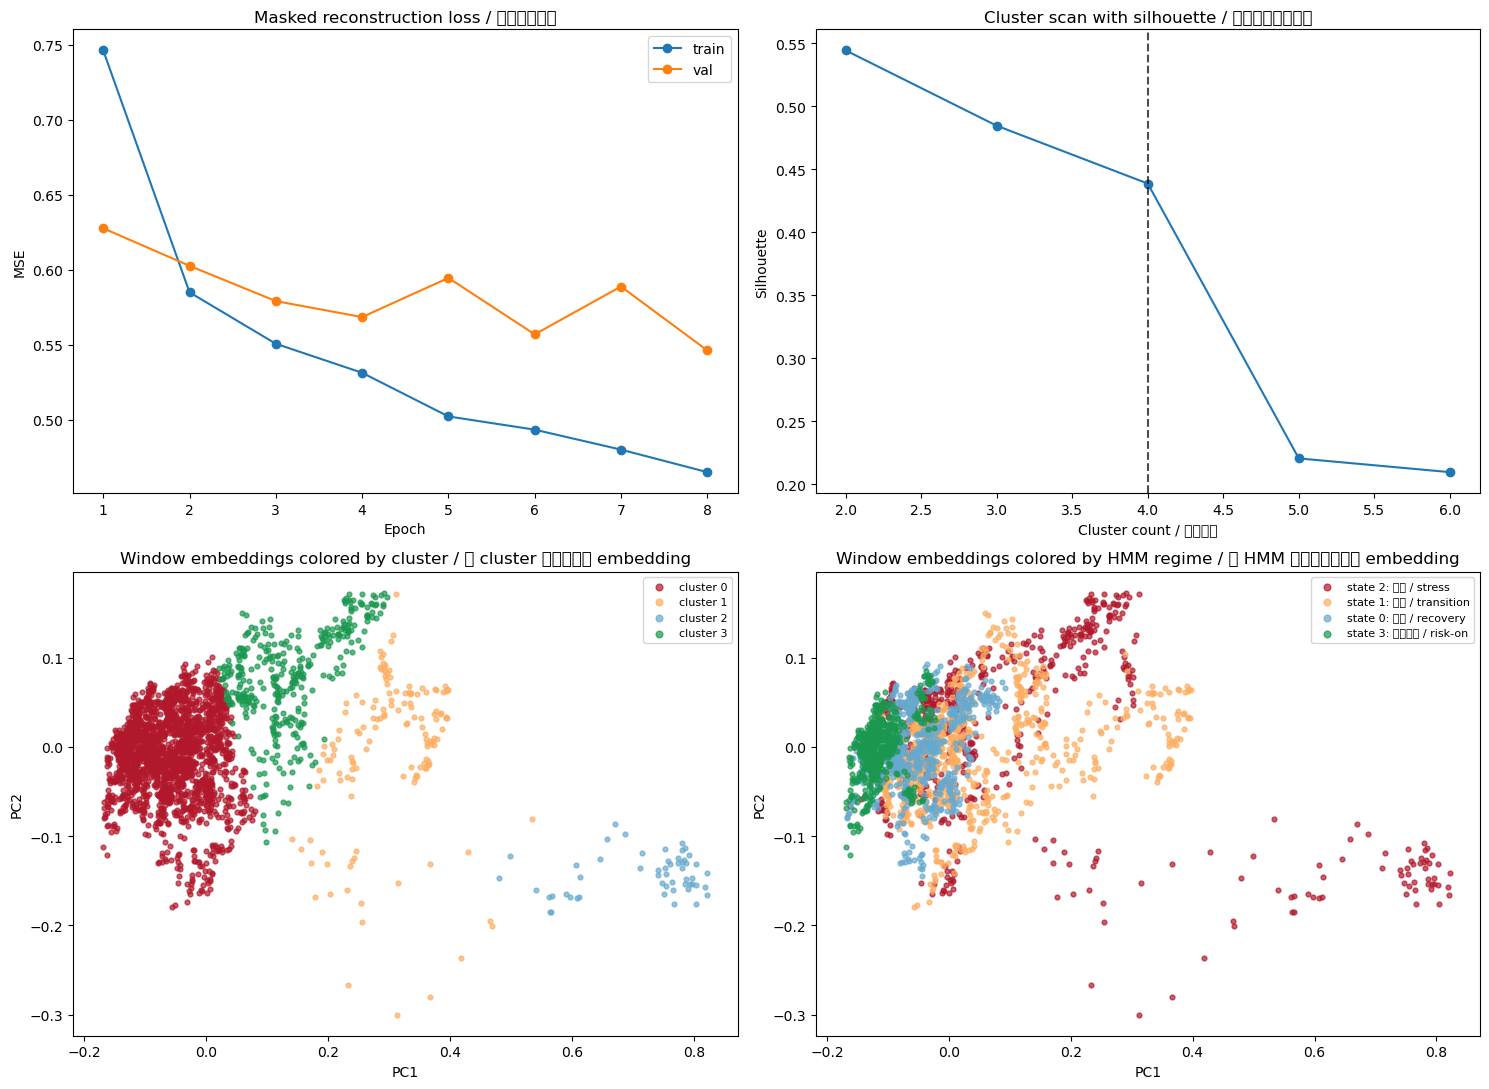

C:\Users\32881\AppData\Local\Temp\ipykernel_13512\215109335.py:124: UserWarning: Glyph 22797 (\N{CJK UNIFIED IDEOGRAPH-590D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32881\AppData\Local\Temp\ipykernel_13512\215109335.py:124: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32881\AppData\Local\Temp\ipykernel_13512\215109335.py:124: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32881\AppData\Local\Temp\ipykernel_13512\215109335.py:124: UserWarning: Glyph 30424 (\N{CJK UNIFIED IDEOGRAPH-76D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32881\AppData\Local\Temp\ipykernel_13512\215109335.py:124: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32881\AppData\Local\Temp\ipykernel_13512\215109335.py:124: UserWarning: Glyph 19982 (\

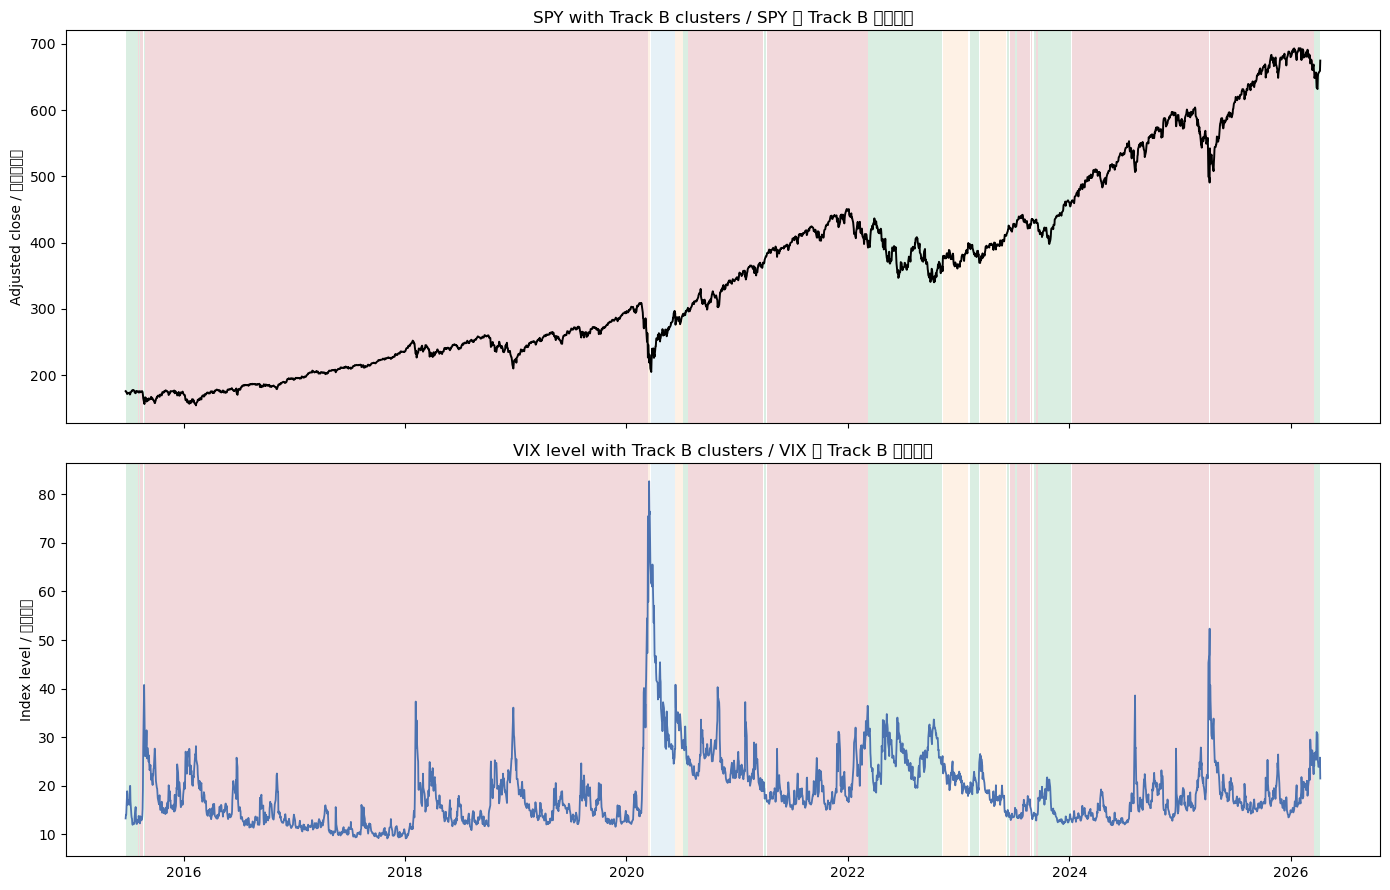

In [7]:
# 先看核心表格，再画图。
# Inspect the core tables first, then render the plots.
print("Reference HMM BIC summary / 参考 HMM 的 BIC 汇总")
display(results["bic_summary"].round(2))

print("Reference HMM state summary / 参考 HMM 状态汇总")
display(results["hmm_state_summary"].round(4))

print("Training history / 训练损失历史")
display(results["history_df"].round(6))

print("Cluster scan / 聚类扫描")
display(results["cluster_scan"].round(4))

print("Comparison table / 聚类与 HMM 对照表")
display(results["comparison_table"])

print("Cluster dominant regime / 每个 cluster 的主导 HMM 状态")
display(results["cluster_dominant_regime"].round(4))

print("Cluster summary / 聚类摘要")
display(results["cluster_summary"].round(4))

plot_track_b(results)


## 保存与复用 / Save And Reuse

训练完之后，可以把模型、scaler、cluster 模型和训练历史一起保存下来。这样后面需要复用 Track B 时，就不用重新训练。  
After training, you can save the model, scaler, cluster model, and training history together. That lets you reuse Track B later without retraining.


In [ ]:
# 把当前 Track B 结果保存到本地目录，后面可以直接加载复用。
# Save the current Track B bundle locally so it can be loaded later for reuse.
saved_dir = save_track_b_artifacts(results, output_dir="artifacts/track_b_default")
print("Saved directory / 保存目录:", saved_dir)

# 示例：从本地恢复保存好的 Track B 模型与配套对象。
# Example: restore the saved Track B model bundle from disk.
loaded_bundle = load_track_b_artifacts(saved_dir)
print("Loaded best epoch / 读取到的最佳轮数:", loaded_bundle["metadata"]["best_epoch"])
print("Loaded best val loss / 读取到的最佳验证损失:", round(loaded_bundle["metadata"]["best_val_loss"], 6))


## How to read Track B / 怎么读 Track B 结果

- 如果 `train_loss` 和 `val_loss` 都能下降，说明 masked reconstruction 学到了有用结构。  
  If both `train_loss` and `val_loss` go down, the masked reconstruction task is learning useful structure.
- 如果中途出现 `Early stopping / 提前停止`，说明验证集已经不再继续改善。  
  If `Early stopping / 提前停止` appears midway, the validation loss has stopped improving.
- `comparison_table` 越集中，说明 cluster 和 HMM regime 的对应关系越明显。  
  The more concentrated `comparison_table` is, the clearer the mapping between clusters and HMM regimes becomes.
